<h1><i>Proyecto: Predicción de Enfermedades Cardiácas</i></h1>
<p> <strong><i>Acerca del Dataset:</i></strong>
<br> Este conjunto de datos incluye información demográfica, signos vitales e indicadores del estado de salud cardíaca de individuos. Contiene características como edad, género, presión arterial, niveles de colesterol y si la persona ha sufrido un infarto. El conjunto de datos es valioso para analizar tendencias relacionadas con la salud cardiovascular y evaluar los factores de riesgo asociados con enfermedades del corazón. Investigadores y profesionales de la salud pueden utilizar estos datos para identificar patrones, desarrollar modelos predictivos y formular intervenciones personalizadas para la prevención y el manejo de enfermedades cardíacas.</p>
<br>
<a href='https://www.kaggle.com/datasets/mahad049/heart-health-stats-dataset?resource=download'>Heart Health Stats Dataset</a>

<h3> <strong> <i> ¿Porqué Elegí este Proyecto? </i> </strong> </h3>
<p>
Según INEGI, en 2023 se registraron 799,869 defunciones en el país. De estas, 89.5% fueron por enfermedades y problemas relacionados con la salud.
<br>
Las 5 principales causas de muerte fueron:
    <ul>
        <li>- Enfermedades del corazón → primera causa de muerte. </li>
        <li>- Diabetes mellitus. </li>
        <li>- Tumores malignos (cáncer). </li>
        <li>- Accidentes (causa externa, pero dentro del top 5). </li>
        <li>- Enfermedades del hígado </li>
    </ul>
</p>

# 1-) Análisis del Dataset

In [ ]:
import pandas as pd

In [2]:
# Cargar Dataset
URL = '../dataset/Ejercicios/Heart_health.csv'
df = pd.read_csv(URL)
df

,ID,Name,Age,Gender,Height(cm),Weight(kg),Blood Pressure(mmHg),Cholesterol(mg/dL),Glucose(mg/dL),Smoker,Exercise(hours/week),Heart Attack
0,1,John Doe,45,Male,175,80,120/80,200,90,No,3,0
1,2,Jane Smith,35,Female,160,65,110/70,180,80,No,2,0
2,3,Michael Johnson,55,Male,180,85,130/85,220,95,Yes,4,1
3,4,Sarah Brown,40,Female,165,70,115/75,190,85,No,3,0
4,5,David Lee,50,Male,170,75,125/80,210,92,Yes,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
719,710,Ashley Martinez,39,Female,166,68,118/76,195,88,No,3,0
720,711,James Rodriguez,56,Male,179,83,123/80,220,100,No,2,1
721,712,Mary Taylor,43,Female,167,70,120/78,200,92,No,2,0
722,713,Christopher Smith,53,Male,182,86,125/78,225,98,Yes,2,1


In [3]:
# Informacion del DataFrame
print('--> ESTRUCTURA DEL DATASET:\n')
print(df.info(),'\n')
print('--> VALORES NULOS:\n')
print(df.isna().sum(),'\n')
print('--> COLUMNAS:\n')
print(df.columns)


--> ESTRUCTURA DEL DATASET:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 724 entries, 0 to 723
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID                    724 non-null    int64 
 1   Name                  724 non-null    object
 2   Age                   724 non-null    int64 
 3   Gender                724 non-null    object
 4   Height(cm)            724 non-null    int64 
 5   Weight(kg)            724 non-null    int64 
 6   Blood Pressure(mmHg)  724 non-null    object
 7   Cholesterol(mg/dL)    724 non-null    int64 
 8   Glucose(mg/dL)        724 non-null    int64 
 9   Smoker                724 non-null    object
 10  Exercise(hours/week)  724 non-null    int64 
 11  Heart Attack          724 non-null    int64 
dtypes: int64(8), object(4)
memory usage: 68.0+ KB
None 

--> VALORES NULOS:

ID                      0
Name                    0
Age                     0
Gender    

In [ ]:
# desbalanceo del target
print(df['Heart Attack'].value_counts())

print(df['Heart Attack'].value_counts(normalize=True))

Heart Attack
1    434
0    290
Name: count, dtype: int64
Heart Attack
1    0.599448
0    0.400552
Name: proportion, dtype: float64


In [6]:
corr = df.corr(numeric_only=True)['Heart Attack'].sort_values(ascending=False)

strong_corr = corr[abs(corr) > 0.5]

print('Correlaciones mas fuertes con Heart Attack:\n')
strong_corr

Correlaciones mas fuertes con Heart Attack:



Heart Attack            1.000000
Cholesterol(mg/dL)      0.827110
Weight(kg)              0.796367
Glucose(mg/dL)          0.792525
Height(cm)              0.762275
Age                     0.613504
Exercise(hours/week)    0.604951
Name: Heart Attack, dtype: float64

## 1.1-) Representación gráfica de los datos

In [7]:
from matplotlib import pyplot as plt
import seaborn as sns

C:\Users\Marco\AppData\Local\Temp\ipykernel_14092\71216967.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=strong_corr.values, y=strong_corr.index, palette="coolwarm")


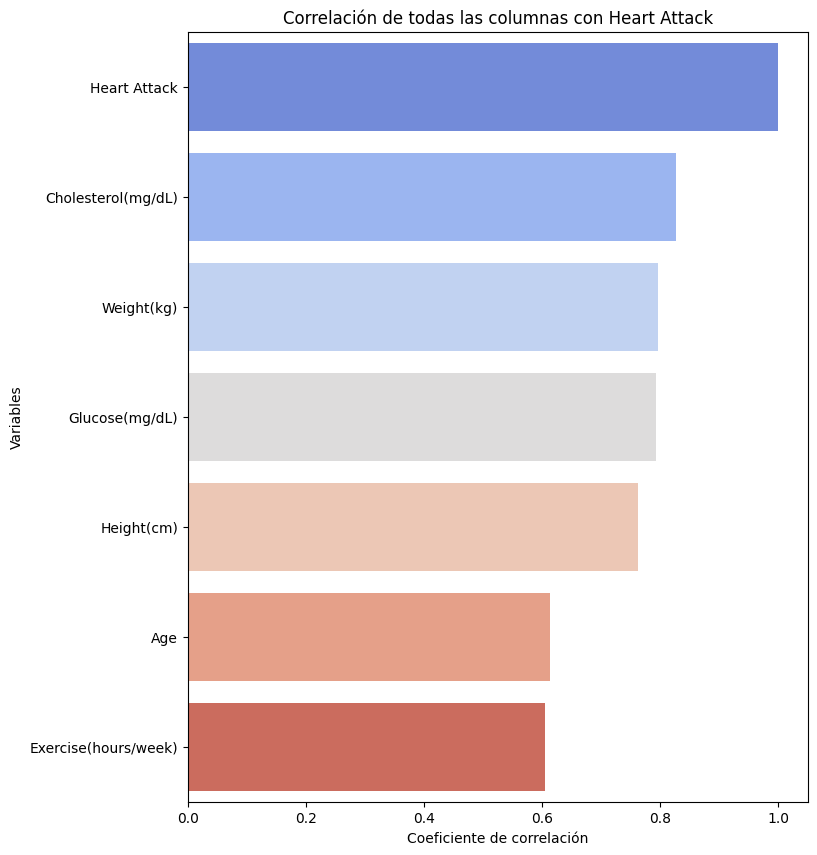

In [11]:
plt.figure(figsize=(8, 10))
sns.barplot(x=strong_corr.values, y=strong_corr.index, palette="coolwarm")

plt.title("Correlación de todas las columnas con Heart Attack")
plt.xlabel("Coeficiente de correlación")
plt.ylabel("Variables")
plt.show()

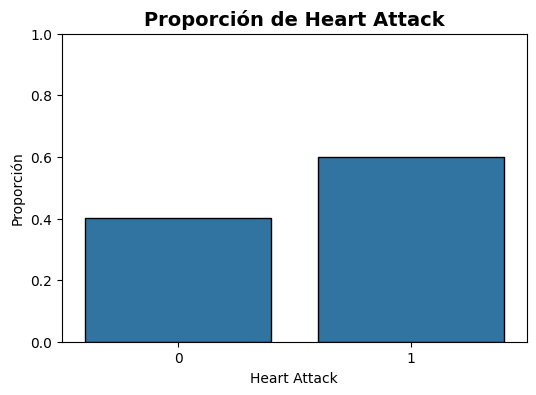

In [12]:
# Proporciones
proportions = df['Heart Attack'].value_counts(normalize=True)

plt.figure(figsize=(6,4))
sns.barplot(x=proportions.index, y=proportions.values, edgecolor="black")

plt.title("Proporción de Heart Attack", fontsize=14, weight="bold")
plt.xlabel("Heart Attack")
plt.ylabel("Proporción")
plt.ylim(0,1)
plt.show()

# 2-) Construcción del Modelo

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

## 2.1 Auxiliares

In [14]:
def train_val_test_split(df, rstate=42, shuffle=True, stratify=None):
    strat = df[stratify] if stratify else None
    train_set, test_set = train_test_split(
        df, test_size=0.4, random_state=rstate, shuffle=shuffle, stratify=strat)
    strat = test_set[stratify] if stratify else None
    val_set, test_set = train_test_split(
        test_set, test_size=0.5, random_state=rstate, shuffle=shuffle, stratify=strat)
    return (train_set, val_set, test_set)

In [20]:
def remove_labels(df, label_name):
    X = df.drop(label_name, axis=1)
    y = df[label_name].copy()
    return (X, y)

In [15]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

In [16]:
class CustomOneHotEncoder(BaseEstimator, TransformerMixin):

    def __init__(self):
        self._oh = OneHotEncoder()
        self._columns = None

    def fit(self, X, y=None):
        X_cat = X.select_dtypes(include=['object'])
        self._columns = pd.get_dummies(X_cat).columns
        self._oh.fit(X_cat)
        return self

    def transform(self, X, y=None):
        X_copy = X.copy()
        X_cat = X_copy.select_dtypes(include=['object'])
        X_num = X_copy.select_dtypes(exclude=['object'])
        X_cat_oh = self._oh.transform(X_cat)
        X_cat_oh = pd.DataFrame(X_cat_oh.toarray(),
                                columns=self._columns,
                                index=X_copy.index)
        X_copy.drop(list(X_cat), axis=1, inplace=True)
        return X_copy.join(X_cat_oh)

In [17]:
class DataFramePreparer(BaseEstimator, TransformerMixin):

    def __init__(self):
        self._full_pipeline = None
        self._columns = None

    def fit(self, X, y=None):
        num_attribs = list(X.select_dtypes(exclude=['object']))
        cat_attribs = list(X.select_dtypes(include=['object']))
        self._full_pipeline = ColumnTransformer([
                ("num", num_pipeline, num_attribs),
                ("cat", CustomOneHotEncoder(), cat_attribs),
        ])
        self._full_pipeline.fit(X)
        self._columns = pd.get_dummies(X).columns
        return self

    def transform(self, X, y=None):
        X_copy = X.copy()
        X_prep = self._full_pipeline.transform(X_copy)
        return pd.DataFrame(X_prep,
                            columns=self._columns,
                            index=X_copy.index)

## 2.2-) Dividir el conjunto de datos

In [ ]:
# eliminar columnas sin correlacion
df[['Systolic', 'Diastolic']] = df['Blood Pressure(mmHg)'].str.split('/', expand=True).astype(int)

df = df.drop(columns=['ID', 'Name', 'Blood Pressure(mmHg)'])

In [93]:
df.describe

<bound method NDFrame.describe of      Age  Gender  Height(cm)  Weight(kg)  Cholesterol(mg/dL)  Glucose(mg/dL)  \
0     45    Male         175          80                 200              90   
1     35  Female         160          65                 180              80   
2     55    Male         180          85                 220              95   
3     40  Female         165          70                 190              85   
4     50    Male         170          75                 210              92   
..   ...     ...         ...         ...                 ...             ...   
719   39  Female         166          68                 195              88   
720   56    Male         179          83                 220             100   
721   43  Female         167          70                 200              92   
722   53    Male         182          86                 225              98   
723   47  Female         170          73                 205              94   

    S

In [78]:
train_set, val_set, test_set = train_val_test_split(df, stratify='Heart Attack')

In [79]:
print(f'Longitud del set de entrenamiento: {len(train_set)}')
print(f'Longitud del set de validacion: {len(val_set)}')
print(f'Longitud del set de pruebas: {len(test_set)}')

Longitud del set de entrenamiento: 434
Longitud del set de validacion: 145
Longitud del set de pruebas: 145


In [80]:
target = 'Heart Attack'

In [81]:
X_train, y_train = remove_labels(train_set, target)
X_val, y_val = remove_labels(val_set, target)
X_test, y_test = remove_labels(test_set, target)

## 2.3-) Entrenar Modelo de regresión logística

In [82]:
pipe = Pipeline([
    ("prep", DataFramePreparer()),
    ("clf", LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        class_weight="balanced",
        C=1.0
    ))
])

In [83]:
pipe.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'


## 2.4-) Métricas del modelo

In [84]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

In [85]:
y_val_pred = pipe.predict(X_val)
y_val_proba = pipe.predict_proba(X_val)[:,1]

print("Validation Report:\n", classification_report(y_val, y_val_pred))
print("Validation ROC-AUC:", roc_auc_score(y_val, y_val_proba))

Validation Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        58
           1       1.00      1.00      1.00        87

    accuracy                           1.00       145
   macro avg       1.00      1.00      1.00       145
weighted avg       1.00      1.00      1.00       145

Validation ROC-AUC: 1.0


In [86]:
y_test_pred = pipe.predict(X_test)
y_test_proba = pipe.predict_proba(X_test)[:,1]

print("Test Report:\n", classification_report(y_test, y_test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_proba))

Test Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        58
           1       1.00      1.00      1.00        87

    accuracy                           1.00       145
   macro avg       1.00      1.00      1.00       145
weighted avg       1.00      1.00      1.00       145

Test ROC-AUC: 1.0


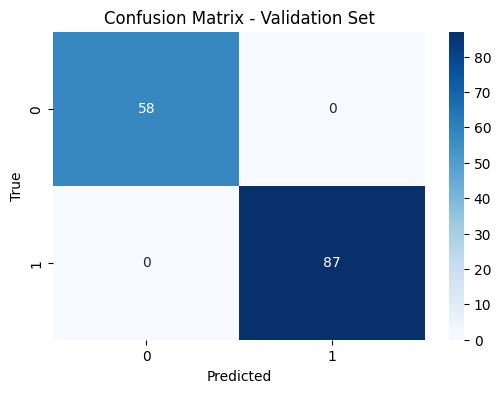

In [87]:
cm = confusion_matrix(y_val, y_val_pred)

# Graficar con seaborn
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=[0,1], yticklabels=[0,1])

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Validation Set")
plt.show()

# 3-) Predicción de nuevas entradas

In [103]:
# 20 nuevas entradas ficticias
df_samples = pd.DataFrame([
    {"Age": 64, "Gender": "Male", "Height(cm)": 176, "Weight(kg)": 85, "Cholesterol(mg/dL)": 250, "Glucose(mg/dL)": 105,
     "Smoker": "Yes", "Exercise(hours/week)": 1, "Heart Attack": 1, "Systolic": 145, "Diastolic": 90},
    {"Age": 34, "Gender": "Female", "Height(cm)": 162, "Weight(kg)": 64, "Cholesterol(mg/dL)": 180, "Glucose(mg/dL)": 82,
     "Smoker": "No", "Exercise(hours/week)": 5, "Heart Attack": 0, "Systolic": 112, "Diastolic": 72},
    {"Age": 57, "Gender": "Male", "Height(cm)": 178, "Weight(kg)": 86, "Cholesterol(mg/dL)": 235, "Glucose(mg/dL)": 100,
     "Smoker": "Yes", "Exercise(hours/week)": 2, "Heart Attack": 1, "Systolic": 138, "Diastolic": 86},
    {"Age": 42, "Gender": "Female", "Height(cm)": 165, "Weight(kg)": 70, "Cholesterol(mg/dL)": 190, "Glucose(mg/dL)": 88,
     "Smoker": "No", "Exercise(hours/week)": 4, "Heart Attack": 0, "Systolic": 115, "Diastolic": 75},
    {"Age": 68, "Gender": "Male", "Height(cm)": 180, "Weight(kg)": 90, "Cholesterol(mg/dL)": 275, "Glucose(mg/dL)": 110,
     "Smoker": "Yes", "Exercise(hours/week)": 0, "Heart Attack": 1, "Systolic": 158, "Diastolic": 95},
    {"Age": 48, "Gender": "Female", "Height(cm)": 167, "Weight(kg)": 72, "Cholesterol(mg/dL)": 205, "Glucose(mg/dL)": 93,
     "Smoker": "No", "Exercise(hours/week)": 3, "Heart Attack": 0, "Systolic": 122, "Diastolic": 79},
    {"Age": 72, "Gender": "Male", "Height(cm)": 177, "Weight(kg)": 92, "Cholesterol(mg/dL)": 285, "Glucose(mg/dL)": 115,
     "Smoker": "Yes", "Exercise(hours/week)": 0, "Heart Attack": 1, "Systolic": 160, "Diastolic": 96},
    {"Age": 40, "Gender": "Female", "Height(cm)": 163, "Weight(kg)": 68, "Cholesterol(mg/dL)": 195, "Glucose(mg/dL)": 89,
     "Smoker": "No", "Exercise(hours/week)": 5, "Heart Attack": 0, "Systolic": 118, "Diastolic": 77},
    {"Age": 61, "Gender": "Male", "Height(cm)": 175, "Weight(kg)": 83, "Cholesterol(mg/dL)": 240, "Glucose(mg/dL)": 100,
     "Smoker": "Yes", "Exercise(hours/week)": 1, "Heart Attack": 1, "Systolic": 140, "Diastolic": 90},
    {"Age": 37, "Gender": "Female", "Height(cm)": 160, "Weight(kg)": 65, "Cholesterol(mg/dL)": 182, "Glucose(mg/dL)": 84,
     "Smoker": "No", "Exercise(hours/week)": 6, "Heart Attack": 0, "Systolic": 110, "Diastolic": 70},
    {"Age": 66, "Gender": "Male", "Height(cm)": 179, "Weight(kg)": 88, "Cholesterol(mg/dL)": 265, "Glucose(mg/dL)": 107,
     "Smoker": "Yes", "Exercise(hours/week)": 1, "Heart Attack": 1, "Systolic": 150, "Diastolic": 92},
    {"Age": 45, "Gender": "Female", "Height(cm)": 166, "Weight(kg)": 71, "Cholesterol(mg/dL)": 200, "Glucose(mg/dL)": 91,
     "Smoker": "No", "Exercise(hours/week)": 3, "Heart Attack": 0, "Systolic": 120, "Diastolic": 78},
    {"Age": 59, "Gender": "Male", "Height(cm)": 181, "Weight(kg)": 86, "Cholesterol(mg/dL)": 238, "Glucose(mg/dL)": 99,
     "Smoker": "Yes", "Exercise(hours/week)": 2, "Heart Attack": 1, "Systolic": 137, "Diastolic": 85},
    {"Age": 39, "Gender": "Female", "Height(cm)": 161, "Weight(kg)": 66, "Cholesterol(mg/dL)": 185, "Glucose(mg/dL)": 83,
     "Smoker": "No", "Exercise(hours/week)": 5, "Heart Attack": 0, "Systolic": 112, "Diastolic": 72},
    {"Age": 70, "Gender": "Male", "Height(cm)": 178, "Weight(kg)": 90, "Cholesterol(mg/dL)": 280, "Glucose(mg/dL)": 112,
     "Smoker": "Yes", "Exercise(hours/week)": 0, "Heart Attack": 1, "Systolic": 160, "Diastolic": 95},
    {"Age": 44, "Gender": "Female", "Height(cm)": 164, "Weight(kg)": 69, "Cholesterol(mg/dL)": 198, "Glucose(mg/dL)": 90,
     "Smoker": "No", "Exercise(hours/week)": 4, "Heart Attack": 0, "Systolic": 118, "Diastolic": 76},
    {"Age": 63, "Gender": "Male", "Height(cm)": 176, "Weight(kg)": 84, "Cholesterol(mg/dL)": 242, "Glucose(mg/dL)": 101,
     "Smoker": "Yes", "Exercise(hours/week)": 1, "Heart Attack": 1, "Systolic": 141, "Diastolic": 89},
    {"Age": 35, "Gender": "Female", "Height(cm)": 160, "Weight(kg)": 64, "Cholesterol(mg/dL)": 180, "Glucose(mg/dL)": 82,
     "Smoker": "No", "Exercise(hours/week)": 6, "Heart Attack": 0, "Systolic": 110, "Diastolic": 70},
    {"Age": 69, "Gender": "Male", "Height(cm)": 177, "Weight(kg)": 89, "Cholesterol(mg/dL)": 270, "Glucose(mg/dL)": 109,
     "Smoker": "Yes", "Exercise(hours/week)": 0, "Heart Attack": 1, "Systolic": 156, "Diastolic": 93},
    {"Age": 46, "Gender": "Female", "Height(cm)": 167, "Weight(kg)": 71, "Cholesterol(mg/dL)": 205, "Glucose(mg/dL)": 93,
     "Smoker": "No", "Exercise(hours/week)": 3, "Heart Attack": 0, "Systolic": 122, "Diastolic": 79}
])

df_samples

,Age,Gender,Height(cm),Weight(kg),Cholesterol(mg/dL),Glucose(mg/dL),Smoker,Exercise(hours/week),Heart Attack,Systolic,Diastolic
0,64,Male,176,85,250,105,Yes,1,1,145,90
1,34,Female,162,64,180,82,No,5,0,112,72
2,57,Male,178,86,235,100,Yes,2,1,138,86
3,42,Female,165,70,190,88,No,4,0,115,75
4,68,Male,180,90,275,110,Yes,0,1,158,95
5,48,Female,167,72,205,93,No,3,0,122,79
6,72,Male,177,92,285,115,Yes,0,1,160,96
7,40,Female,163,68,195,89,No,5,0,118,77
8,61,Male,175,83,240,100,Yes,1,1,140,90
9,37,Female,160,65,182,84,No,6,0,110,70


In [104]:
X_new, y_true = remove_labels(df_samples, target)

In [105]:
y_true_pred = pipe.predict(X_new)
y_true_proba = pipe.predict_proba(X_new)[:,1]

print("Validation Report:\n", classification_report(y_true, y_true_pred))
print("Validation ROC-AUC:", roc_auc_score(y_true, y_true_proba))

Validation Report:
               precision    recall  f1-score   support

           0       1.00      0.80      0.89        10
           1       0.83      1.00      0.91        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20

Validation ROC-AUC: 1.0


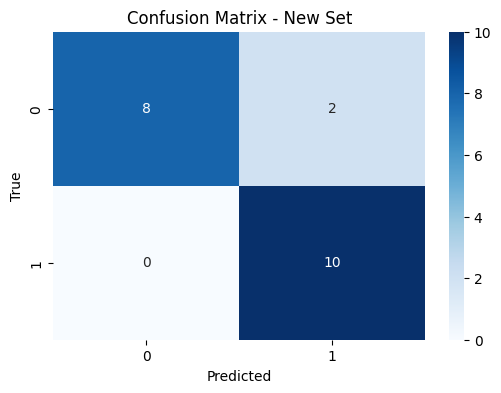

In [107]:
cm = confusion_matrix(y_true, y_true_pred)

# Graficar con seaborn
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=[0,1], yticklabels=[0,1])

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - New Set")
plt.show()